# 0.5.7 — What Do the Top 3 (by Profit $) Have in Common?

Central America, Western Europe, South America. Part of [`0.5_by_region_analysis.ipynb`](0.5_by_region_analysis.ipynb) — deep dives on each individually live in [`0.5.2`](0.5.2_deepdive_central_america.ipynb), [`0.5.1`](0.5.1_deepdive_western_europe.ipynb), [`0.5.3`](0.5.3_deepdive_south_america.ipynb).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

CATEGORICAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
BLUE, ORANGE = CATEGORICAL[0], CATEGORICAL[1]
POS, NEG = '#2a78d6', '#e34948'
INK = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRID = '#e1e0d9'
SURFACE = '#fcfcfb'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'axes.edgecolor': GRID,
    'axes.labelcolor': INK_SECONDARY, 'text.color': INK,
    'xtick.color': INK_MUTED, 'ytick.color': INK_MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'font.size': 10,
})

def style_axis(ax, x_grid=False, y_grid=True):
    if x_grid: ax.grid(axis='x', zorder=0)
    if y_grid: ax.grid(axis='y', zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)

def usd(x, pos=None):
    if abs(x) >= 1000:
        return f"${x:,.0f}"
    return f"${x:,.1f}"

USD_FMT = mticker.FuncFormatter(usd)
DATA_DIR = '.'

In [2]:
df_full = pd.read_csv(f'{DATA_DIR}/DataCoSupplyChainDataset.csv', encoding='latin1')
df_full['order date (DateOrders)'] = pd.to_datetime(df_full['order date (DateOrders)'])
df_full['month'] = df_full['order date (DateOrders)'].dt.to_period('M')

df = df_full[df_full['order date (DateOrders)'] < '2017-10-01'].copy()  # exclude Nov-2017+ order-composition artifact (0.1)
print(f"excluded {len(df_full) - len(df):,} rows from Oct 2017 onward ({(len(df_full)-len(df))/len(df_full)*100:.1f}% of {len(df_full):,})")

TOTAL_PROFIT = df['Order Profit Per Order'].sum()
TOTAL_REVENUE = df['Order Item Total'].sum()

def region_row(region):
    sub = df[df['Order Region'] == region]
    profit = sub['Order Profit Per Order'].sum()
    revenue = sub['Order Item Total'].sum()
    return sub, profit, revenue

_all = df.groupby('Order Region').agg(revenue=('Order Item Total', 'sum'), profit=('Order Profit Per Order', 'sum'),
                                       n=('Order Id', 'size')).reset_index()
_all['margin_pct'] = _all['profit'] / _all['revenue'] * 100
_all['margin_rank'] = _all['margin_pct'].rank(ascending=False).astype(int)
_all['profit_rank'] = _all['profit'].rank(ascending=False).astype(int)
_all['pct_of_company_profit'] = _all['profit'] / TOTAL_PROFIT * 100
RANKS = _all.set_index('Order Region')

print(f"transactions: {df.shape[0]:,} rows across {df['Order Region'].nunique()} regions")
print(f"company total: revenue {usd(TOTAL_REVENUE)}, profit {usd(TOTAL_PROFIT)}")

excluded 8,557 rows from Oct 2017 onward (4.7% of 180,519)
transactions: 171,962 rows across 23 regions
company total: revenue $30,774,234, profit $3,685,985


**Data-generation artifact excluded from here on**: rows from Oct 2017 onward are dropped before any revenue/profit/margin figure below is computed — that window is where order composition breaks (`0.1_company_growth.ipynb` §2: every order collapses to 1 line item, order counts and per-order revenue become non-comparable to earlier months). This affects Western Europe, Northern Europe and Southern Europe's *totals* slightly (they're the only ones of the 6 regions here with any activity that late); it has zero effect on Central America, South America, Central Asia, Canada or Southern Africa, whose data ends earlier anyway. `TOTAL_PROFIT`/`TOTAL_REVENUE` (and therefore every `pct_of_company_profit` figure below) are computed on this same excluded basis, company-wide.

## Side-by-side

In [3]:
TOP3 = ['Western Europe', 'Central America', 'South America']
market_map = df.drop_duplicates('Order Region').set_index('Order Region')['Market']
discount = df.groupby('Order Region')['Order Item Discount Rate'].mean()
late = df.groupby('Order Region')['Late_delivery_risk'].mean()
months_active = df.groupby('Order Region')['month'].nunique()

t = RANKS.loc[TOP3, ['profit', 'revenue', 'margin_pct', 'margin_rank', 'profit_rank', 'n', 'pct_of_company_profit']].copy()
t['market'] = market_map.loc[TOP3]
t['avg_discount'] = discount.loc[TOP3]
t['late_risk'] = late.loc[TOP3]
t['months_with_orders'] = months_active.loc[TOP3]
t.round(3)

,profit,revenue,margin_pct,margin_rank,profit_rank,n,pct_of_company_profit,market,avg_discount,late_risk,months_with_orders
Order Region,,,,,,,,,,,
Western Europe,551026.661,4631249.170,11.898,13,2,25377,14.949,Europe,0.101,0.559,16
Central America,616341.571,5093849.716,12.100,12,1,28341,16.721,LATAM,0.101,0.548,11
South America,335154.401,2660243.689,12.599,7,3,14935,9.093,LATAM,0.102,0.543,11


In [4]:
combined_profit = t['profit'].sum()
print(f"Combined profit of all 3: {usd(combined_profit)} = {combined_profit/TOTAL_PROFIT*100:.2f}% of company profit ({usd(TOTAL_PROFIT)})")
print(f"For comparison, the bottom-3-by-profit group (Central Asia, Canada, Southern Africa) combined generate {usd(RANKS.loc[['Central Asia','Canada','Southern Africa'],'profit'].sum())}")

Combined profit of all 3: $1,502,523 = 40.76% of company profit ($3,685,985)
For comparison, the bottom-3-by-profit group (Central Asia, Canada, Southern Africa) combined generate $67,772


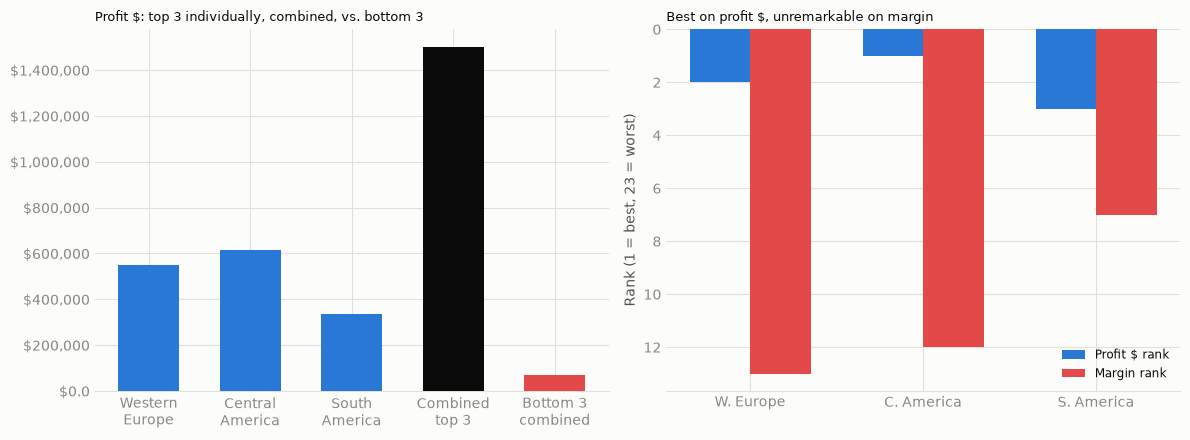

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bot3_combined = RANKS.loc[['Central Asia', 'Canada', 'Southern Africa'], 'profit'].sum()
axes[0].bar(['Western\nEurope', 'Central\nAmerica', 'South\nAmerica', 'Combined\ntop 3', 'Bottom 3\ncombined'],
            [t.loc['Western Europe', 'profit'], t.loc['Central America', 'profit'], t.loc['South America', 'profit'], combined_profit, bot3_combined],
            color=[BLUE, BLUE, BLUE, INK, NEG], zorder=3, width=0.6)
axes[0].yaxis.set_major_formatter(USD_FMT)
axes[0].set_title('Profit $: top 3 individually, combined, vs. bottom 3', loc='left', fontsize=9.5, color=INK)
style_axis(axes[0], y_grid=True)

x = np.arange(3)
w = 0.35
axes[1].bar(x - w/2, t['profit_rank'], width=w, color=BLUE, label='Profit $ rank', zorder=3)
axes[1].bar(x + w/2, t['margin_rank'], width=w, color=NEG, label='Margin rank', zorder=3)
axes[1].set_xticks(x); axes[1].set_xticklabels(['W. Europe', 'C. America', 'S. America'])
axes[1].set_ylabel('Rank (1 = best, 23 = worst)')
axes[1].invert_yaxis()
axes[1].legend(frameon=False, fontsize=8.5)
axes[1].set_title('Best on profit $, unremarkable on margin', loc='left', fontsize=9.5, color=INK)
style_axis(axes[1], y_grid=True)

plt.tight_layout()
plt.show()

## What they share

- **Enormous scale relative to everything else**: 14,935 – 28,341 order lines each, versus 553 – 1,157 for the bottom-3-by-profit group. Revenue alone ($2.66M – $5.09M each) exceeds the *entire* bottom-3-by-profit group's revenue many times over.
- **Ordinary, unremarkable margins** (11.9% – 12.6%) — none of them are anywhere near the top of the margin ranking. They win on profit $ purely by being big, not by being efficient.
- **Multi-month order gaps in the data.** Central America and South America share an identical 19-month dead zone (Jun 2015 – Dec 2016) — they're both LATAM. Western Europe's gap runs on a different calendar but is comparably long.
- **Combined, they generate $1.50M — 40.8% of the entire company's profit** ($3.69M), against just $67.8K (1.8%) for the bottom-3-by-profit group.

## Bottom line

The top 3 by profit $ don't share a secret strategy — they share size. If the room wants to protect company profit, these 3 regions (and specifically not letting their order-flow gaps recur) matter more than anything happening in the margin-leader regions combined.